# Experimentation and Implementation

I plan on using this python notebook as a way to formulate how my neural networks should work. If you are reading this without having read the README.md I will quickly explain the goals of this project:

This project is meant to serve both as an introduction to protein folding via machine learning, and to test the potential strength of a relatively new algorithm named 'ProtTrans' which can take a string of protein residues and transform the input into a string that would be easier to read and train a neural network on for feasable proteins.

As a quick mark, here are the things I need to do in this file:
1) Import protein residue data
2) Processes, refine, and reduce data so that the nn can be trained quickly to experiment and adapt
3) build and train neural network that takes in residues straight.
4) incorporate ProtTrans, feed data in, and store output
5) build and train another neural network on ProtTrans output data
6) Optimize hyperparameters for both neural networks and experiment with various values like depth and # of hidden nodes.
7) print graphs and data to compare and analyize

I am not entirely sure what type of output the cnn should provide, it can either provide a 0-1 value of certainty of contact, then we use a cutoff to decide what is a contact or not, or it can provide a distance metric that we then filter to however many A we want to use to denote a "contact"


# Imports and dependencies

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice
from tqdm import tqdm
import os.path
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available, using CPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


GPU: NVIDIA GeForce RTX 4060 Ti is available.


# Importing Protein Data

I will use the following code box to try and visualize the data given in the 'adataset' pdb file. 

The key features I need to be able to extract are name, length, amino acid residues, and the contact map.

A lot of this is written in a way that should make it easy to apply this to the whole database.

4LGTD
247
['M', 'S', 'E', 'K', 'L', 'Q', 'K', 'V', 'L', 'A', 'R', 'A', 'G', 'H', 'G', 'S', 'R', 'R', 'E', 'I', 'E', 'S', 'I', 'I', 'E', 'A', 'G', 'R', 'V', 'S', 'V', 'D', 'G', 'K', 'I', 'A', 'K', 'L', 'G', 'D', 'R', 'V', 'E', 'V', 'T', 'P', 'G', 'L', 'K', 'I', 'R', 'I', 'D', 'G', 'H', 'L', 'I', 'S', 'V', 'R', 'E', 'S', 'I', 'C', 'R', 'V', 'L', 'A', 'Y', 'Y', 'K', 'P', 'E', 'G', 'E', 'L', 'C', 'T', 'R', 'N', 'D', 'P', 'E', 'G', 'R', 'P', 'T', 'V', 'F', 'D', 'R', 'L', 'P', 'K', 'L', 'R', 'G', 'A', 'R', 'W', 'I', 'A', 'V', 'G', 'R', 'L', 'D', 'V', 'N', 'T', 'X', 'G', 'L', 'L', 'L', 'F', 'T', 'T', 'D', 'G', 'E', 'L', 'A', 'N', 'R', 'L', 'M', 'H', 'P', 'S', 'R', 'E', 'V', 'E', 'R', 'E', 'Y', 'A', 'V', 'R', 'V', 'F', 'G', 'Q', 'V', 'D', 'D', 'A', 'K', 'L', 'R', 'D', 'L', 'S', 'R', 'G', 'V', 'Q', 'L', 'E', 'D', 'G', 'P', 'A', 'A', 'F', 'K', 'T', 'I', 'K', 'F', 'S', 'G', 'G', 'E', 'G', 'I', 'N', 'Q', 'W', 'Y', 'N', 'V', 'T', 'L', 'T', 'E', 'G', 'R', 'N', 'R', 'E', 'V', 'R', 'R', 'L', 'W', 'E',

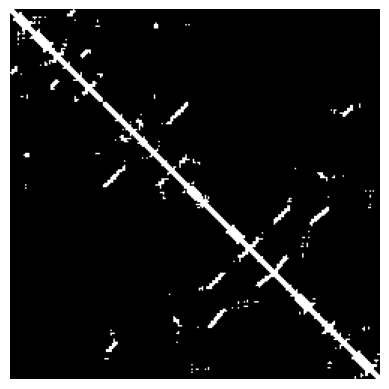

In [2]:
with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
    # Extract the data we need from the slice of the dataset
    segment = list(islice(pdb_adataset, 16))
    data = {"name": [], "length": [], "proteins": [], "xyz": []}
    data["name"].append(segment[0].replace("\n", ""))
    data["length"].append(int(segment[1]))

    # protein and coords need extra care, as they are lists in the dict list
    data["proteins"].append(
        segment[2].replace("\n", "")
            .split("\t")
    )
    del data["proteins"][0][-1]

    data["xyz"].append(
        segment[13].replace("\n", "")
            .split("\t")
        )
    del data["xyz"][0][-1]

    # We are going to use a for loop to turn the xyz coordinates into floats and make the triplet lists
    i = 0
    for string in data["xyz"][0]:
        data["xyz"][0][i] = list(map(float, string.split(" ")))
        i += 1

print(data["name"][0])
print(data["length"][0])
print(data["proteins"][0])
print(len(data["proteins"][0]))
print(data["xyz"][0])
print(len(data["xyz"][0]))

# Calculating and printing the contact map
def createContactMap(coordinates):
    contact = []
    for coord1 in coordinates:
        temp = []
        for coord2 in coordinates:
            distance = np.linalg.norm(np.array(coord1) - np.array(coord2))
            temp.append(distance)
        contact.append(temp)
    return contact

def applyThreshold(tensor, threshold, length):  
    map = []
    for i, line in enumerate(tensor, 0):
        if i == length: break
        temp_line = []
        for element in line[:length]:
            if (element < threshold):
                temp_line.append(1.)
            else:
                temp_line.append(0.)
        map.append(temp_line)
    return map

def printMap(map, size = -1):
    if size > 0:
        newMap = map[:size][:size]
    else:
        newMap = map
    fig, ax = plt.subplots()
    ax.imshow(np.matrix(newMap), cmap='gray')
    ax.axis('off')
    plt.show()

contact = createContactMap(data["xyz"][0])
contact = applyThreshold(contact, 8, data["length"][0])
printMap(contact)

## Loading in data from dataset

This is a large text box, though its functionality is not complicated. The class loads in the data from the file, then encodes the protein resiude list using VHSE encodings, which are then concatenated into pairs to represent the tensors, the train tensors are a Length x Length grid of vectors of length 16 (8 per residue in each pair). The test data takes the coordinates given by the database to make a tensor of L x L with each value being the distance between each protein (as seen above)

Previously calculated statistics:

Max length:  1195 	Min length:  30 	Mean length:  219.79 	Mode length:  233

Chars used in proteins:  {'N', 'F', 'P', 'A', 'D', 'M', 'T', 'G', 'Q', 'H', 'I', 'K', 'W', 'Y', 'X', 'V', 'S', 'E', 'C', 'R', 'L'} 	Count:  21

In [3]:
MAXLENGTH = 200

def generate_data():
    data = {"name": [], "length": [], "proteins": [], "coord": []}
    print("Reading in from dataset files")

    # Read in data from the two files
    with open("pdb.fasta_qual.16Nov2022_30.fasta") as pdb_fasta:
        fasta_lines = pdb_fasta.readlines()[0::2]
    fasta_lines = [s.replace('>', '') for s in fasta_lines]
    fasta_lines = [s.replace('\n', '') for s in fasta_lines]

    
    i = 0

    # Convert data to a usable format and put it in a dictionary
    with open("pdb.fasta_qual.16Nov2022.adataset") as pdb_adataset:
        while True:
            segment = list(islice(pdb_adataset, 16))
            if not segment: # If there are no more lines we break the loop.
                break

            name = segment[0].replace("\n", "")
            if name in fasta_lines:
                length = int(segment[1])
                if (length <= MAXLENGTH):
                    data["name"].append(name)
                    data["length"].append(length)

                    # Residue data
                    proteins = segment[2].replace("\n", "").split("\t")
                    del proteins[-1]
                    data["proteins"].append(proteins)

                    # Coordinate data
                    coords = segment[13].replace("\n", "").split("\t")
                    del coords[-1]

                    i = 0
                    for string in coords:
                        coords[i] = list(map(float, string.split(" ")))
                        i += 1
                    data["coord"].append(coords) 
    print("Finished reading from files.")   

    print(f"Name: {data['name'][0]} \tLength: {data['length'][0]} \nResidue Chain: {data['proteins'][0]} \nCoordinates: {data['coord'][0]}")
    return data

## VHSE Dataset
This is the dataset that converts the previously imported data into the VHSE encodings. It stores the encodings, target contact map, and length in a file. getitem reads from that file and returns the tensor that is actually input into the CNN.

In [ ]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import linecache
import ast

class vhseDataset(Dataset):
    vhse_map = {
        'A': [0.15, -1.11, -1.35, -0.92, 0.02, -0.91, 0.36, -0.48],
        'R': [-1.47, 1.45, 1.24, 1.27, 1.55, 1.47, 1.3, 0.83],
        'N': [-0.99, 0, -0.37, 0.69, -0.55, 0.85, 0.74, -0.8],
        'D': [-1.15, 0.67, -0.41, -0.01, -2.68, 1.31, 0.03, 0.56],
        'C': [0.18, -1.67, -0.46, -0.21, 0, 1.2, -1.61, -0.19],
        'Q': [-0.96, 0.12, 0.18, 0.16, 0.09, 0.42, -0.2, -0.41],
        'E': [-1.18, 0.4, 0.1, 0.36, -21.6, -0.17, 0.91, 0.02],
        'G': [-0.2, -1.53, -2.63, 2.28, -0.53, -1.18, 2.01, -1.34],
        'H': [-0.43, -0.25, 0.37, 0.19, 0.51, 1.28, 0.93, 0.65],
        'I': [1.27, -0.14, 0.3, -1.8, 0.3, -1.61, -0.16, -0.13],
        'L': [1.36, 0.07, 0.26, -0.8, 0.22, -1.37, 0.08, -0.62],
        'K': [-1.17, 0.7, 0.7, 0.8, 1.64, 0.67, 1.63, 0.13],
        'M': [1.01, -0.53, 0.43, 0, 0.23, 0.1, -0.86, -0.68],
        'F': [1.52, 0.61, 0.96, -0.16, 0.25, 0.28, -1.33, -.02],
        'P': [0.22, -0.17, -0.5, 0.05, -0.01, -1.34, -0.19, 3.56],
        'S': [-0.67, -0.88, -1.07, -0.41, -0.32, 0.27, -0.64, 0.11],
        'T': [-0.34, -0.51, -0.55, -1.06, 0.01, -0.01, -0.79, 0.39],
        'W': [1.5, 2.06, 1.79, 0.75, 0.75, -0.13, -1.06, -0.85],
        'Y': [0.61, 1.6, 1.17, 0.73, 0.53, 0.25, -0.96, -0.52],
        'V': [0.76, -0.92, 0.17, -1.91, 0.22, -1.4, -0.24, -0.03],
        'X': [0, 0, 0, 0, 0, 0, 0, 0],
    }

    def __init__(self, num_data = -1, test = False):
        self.length = 0
        # If we are using all the data there is no need to seperate the two
        if num_data == -1:
            test = False
            
        if test:
            self.file = f"pdb-vhsetest{num_data}"
        else:
            self.file = f"pdb-vhse{num_data}"
        # Check to see if the necessary file exists, if it doesn't, create it
        if not os.path.isfile(self.file):
            # If the data hasn't been loaded from the file, do so.
            data = generate_data()

            # Cut data based on specified length. 'test' dataset takes from the end of the data
            if num_data >= 1:
                if test:
                    dataset = {key: value[-num_data:] for key, value in data.items()}
                else:
                    dataset = {key: value[:num_data] for key, value in data.items()}
            else:
                dataset = data
                
            
            with open(self.file, 'x') as pdb:
                for i, protein in enumerate(tqdm(dataset['proteins'])):
                    # Encode the protein residues based on the VHSE encodings dictionary
                    encoding = []
                    for residue in protein:
                        encoding.append(self.vhse_map[residue])

                    encoding = list(encoding)
                    pdb.write(f"{encoding}\n")

                    length = dataset['length'][i]
                    
                    # Convert residue coords to distances
                    protein = dataset['coord'][i]
                    protein = np.array(protein)
                    tensor = protein[:, None, :] - protein[None, :, :]
                    tensor = np.linalg.norm(tensor, axis=2)
                    tensor = applyThreshold(tensor, 8, length)
                    pdb.write(f"{tensor}\n")

                    pdb.write(f"{length}\n")

                    self.length += 1

        else:
            with open(self.file) as pdb:
                self.length = int(sum(1 for line in pdb) / 3)
    
    def __len__(self):
        return self.length
    
    # I have made this a drive-read class for memory reasons, it will be much slower but hopefully wont consume over 32gb of memory
    def __getitem__(self, index):
        f_i = (index * 3) + 1

        # Import encodings from file
        line = linecache.getline(self.file, f_i)
        protein = line.replace("\n", "")
        protein = np.array(ast.literal_eval(protein))
        protein = np.float32(protein)
        # I make a 32-length vector based on the pair of encodings
        tensor = np.concatenate([
                    protein[:, None, :] + np.zeros_like(protein[None, :, :]),  # features of first residue
                    protein[None, :, :] + np.zeros_like(protein[:, None, :]),  # features of second residue
                    protein[:, None, :] - protein[None, :, :],                 # difference
                    protein[:, None, :] * protein[None, :, :]                  # sum
                    ], axis=-1)
        tensor = torch.tensor(tensor)
        tensor = tensor.permute(2, 0, 1)
        

        # Import length
        line = linecache.getline(self.file, f_i + 2)
        length = line.replace("\n", "")
        length = np.int64(length)

        # Import coordinate map
        line = linecache.getline(self.file, f_i + 1)
        map = line.replace("\n", "")
        map = np.array(ast.literal_eval(map))
        map = np.float32(map)
        map = torch.tensor(map).unsqueeze(0)

        linecache.checkcache()

        return tensor, map, length

### Visualize the VHSE dataset, and ensure its functionality 

In [5]:
batch = 1 # I am setting the batch size to 1, as the dataloaders don't like different size tensors, and thus wouldnt allow a FCNN
count = -1  # -1 Does all data
train_data = vhseDataset(num_data = count)
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_data = vhseDataset(num_data = 1000, test = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle=True)

torch.Size([1, 32, 160, 160])
tensor([1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600, 1.3600,
        1.

c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchshow\visualization.py:385: UserWarning: Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.
  warnings.warn('Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.')


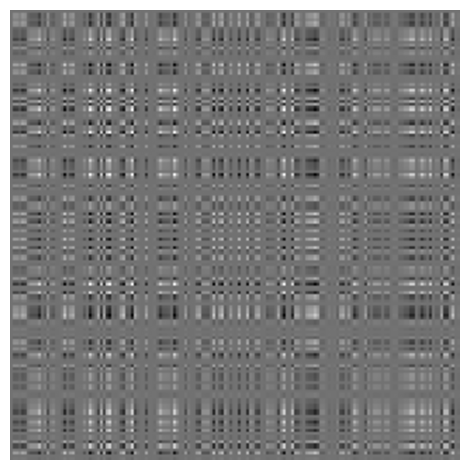

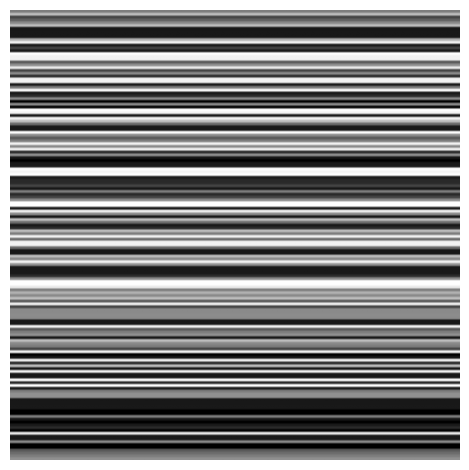

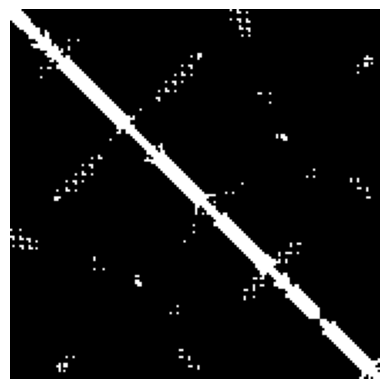

tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]]])


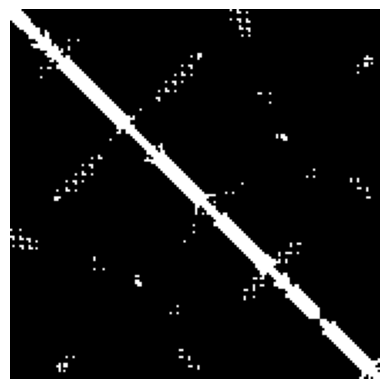

In [6]:
import torchshow
trainiter = iter(train_loader)

# Train data
train, target, length = next(trainiter)
print(train.shape)
train = train.squeeze(0)
torchshow.show(train[25])
print(f"{train[0][25]}")
# This doesn't look how I expected it to, but the printed tensor does
torchshow.show(train[0])

# Target data
target = target[0]
#print(target)
printMap(target.squeeze(0))
print(target)
printMap(target.squeeze(0), length[0])

## ProtTrans Encodings & Dataset
The first box is a set of methods given by the ProtTrans colab at: https://colab.research.google.com/drive/1TUj-ayG3WO52n5N50S7KH9vtt6zRkdmj?usp=sharing#scrollTo=nK4hwGggR_Rs 
This will generate the encodings for each protein when called. It is worth noting however that I have removed the structural protein data for now as there was issues with it. I will also add back the protein embeddings if I get access to a more powerful machine.
The second box uses those methods to create a dataset, that reads in the protein residues, encodes them, writes them to file, then retrieves them when necessary.

In [7]:
# Embedding generation from ProtTrans Colab: https://colab.research.google.com/drive/1TUj-ayG3WO52n5N50S7KH9vtt6zRkdmj?usp=sharing#scrollTo=nK4hwGggR_Rs 
import time
from transformers import T5EncoderModel, T5Tokenizer

def get_T5_model():
    model = T5EncoderModel.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc")
    model = model.to(device) # move model to GPU
    model = model.eval() # set model to evaluation model
    tokenizer = T5Tokenizer.from_pretrained('Rostlab/prot_t5_xl_half_uniref50-enc', do_lower_case=False)

    return model, tokenizer

#@title Generate embeddings. { display-mode: "form" }
# Generate embeddings via batch-processing
# per_residue indicates that embeddings for each residue in a protein should be returned.
# per_protein indicates that embeddings for a whole protein should be returned (average-pooling)
# max_residues gives the upper limit of residues within one batch
# max_seq_len gives the upper sequences length for applying batch-processing
# max_batch gives the upper number of sequences per batch
def get_embeddings( model, tokenizer, seqs, per_residue, per_protein,
                   max_residues=4000, max_seq_len=1000, max_batch=100 ):

    results = {"residue_embs" : dict(),
               "protein_embs" : dict(),
               "sec_structs" : dict()
               }

    # sort sequences according to length (reduces unnecessary padding --> speeds up embedding)
    seq_dict   = sorted( seqs.items(), key=lambda kv: len( seqs[kv[0]] ), reverse=True )
    start = time.time()
    batch = list()
    for seq_idx, (pdb_id, seq) in enumerate(seq_dict,1):
        seq = seq
        seq_len = len(seq)
        seq = ' '.join(list(seq))
        batch.append((pdb_id,seq,seq_len))

        # count residues in current batch and add the last sequence length to
        # avoid that batches with (n_res_batch > max_residues) get processed
        n_res_batch = sum([ s_len for  _, _, s_len in batch ]) + seq_len
        if len(batch) >= max_batch or n_res_batch>=max_residues or seq_idx==len(seq_dict) or seq_len>max_seq_len:
            pdb_ids, seqs, seq_lens = zip(*batch)
            batch = list()

            # add_special_tokens adds extra token at the end of each sequence
            #token_encoding = tokenizer.batch_encode_plus(seqs, add_special_tokens=True, padding="longest")
            token_encoding = tokenizer(seqs, padding="longest", add_special_tokens=True, return_tensors="pt")
            input_ids      = torch.tensor(token_encoding['input_ids']).to(device)
            attention_mask = torch.tensor(token_encoding['attention_mask']).to(device)

            try:
                with torch.no_grad():
                    # returns: ( batch-size x max_seq_len_in_minibatch x embedding_dim )
                    embedding_repr = model(input_ids, attention_mask=attention_mask)
            except RuntimeError:
                print("RuntimeError during embedding for {} (L={})".format(pdb_id, seq_len))
                continue


            for batch_idx, identifier in enumerate(pdb_ids): # for each protein in the current mini-batch
                s_len = seq_lens[batch_idx]
                # slice off padding --> batch-size x seq_len x embedding_dim
                emb = embedding_repr.last_hidden_state[batch_idx,:s_len]
                if per_residue: # store per-residue embeddings (Lx1024)
                    results["residue_embs"][ identifier ] = emb.detach().cpu().numpy().squeeze()
                if per_protein: # apply average-pooling to derive per-protein embeddings (1024-d)
                    protein_emb = emb.mean(dim=0)
                    results["protein_embs"][identifier] = protein_emb.detach().cpu().numpy().squeeze()


    passed_time=time.time()-start
    avg_time = passed_time/len(results["residue_embs"]) if per_residue else passed_time/len(results["protein_embs"])
    print('\n############# EMBEDDING STATS #############')
    print('Total number of per-residue embeddings: {}'.format(len(results["residue_embs"])))
    print('Total number of per-protein embeddings: {}'.format(len(results["protein_embs"])))
    print("Time for generating embeddings: {:.1f}[m] ({:.3f}[s/protein])".format(
        passed_time/60, avg_time ))
    print('\n############# END #############')
    return results

c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### PT Dataset Class
I will explain this code less, as it is quite similar to the VHSE dataset

In [ ]:
class ptDataset(Dataset):

    def __init__(self, data, num_data = -1, test = False):
        self.length = 0
        # If we are using all the data there is no need to seperate the two
        if num_data == -1:
            test = False
        if test:
            self.file = f"pdb-pttest{num_data}"
        else:
            self.file = f"pdb-pt{num_data}"
        
        if not os.path.isfile(self.file):

            data = generate_data()

            if num_data >= 1:
                if test:
                    dataset = {key: value[-num_data:] for key, value in data.items()}
                else:
                    dataset = {key: value[:num_data] for key, value in data.items()}
            else:
                dataset = data

            # I need to sort the dataset items in the same way as the embedding method so the data aligns
            indices = sorted(range(len(dataset['length'])), key=lambda i: dataset['length'][i], reverse=True)
            dataset = {key: [value[i] for i in indices] for key, value in dataset.items()}
                        
            # We need to convert the data to a dictionary that the prot-trans method can read
            # This should maintain order, so I can still use dataset
            sequences = {key: value for key, value in zip(dataset['name'], dataset['proteins'])}
            
            with open(self.file, 'x') as pdb:
                model, tokenizer = get_T5_model()
                # I am not sure how to implement the 1024x1 protein-embedding vector, so we will avoid it for now
                results = get_embeddings(model, tokenizer, sequences, True, False)
                for i, data in enumerate(tqdm(results['residue_embs'].items())):
                    key, value = data

                    # I write length first as it was important to retrieve first before, now the CNN is fully convolutional it's simply a vestigial remnant.
                    length = dataset['length'][i]
                    pdb.write(f"{length}\n")

                    pdb.write(f"{np.ndarray.tolist(value)}\n")

                    # Convert residue coords to distances
                    protein = dataset['coord'][i]
                    protein = np.array(protein)
                    tensor = protein[:, None, :] - protein[None, :, :]
                    tensor = np.linalg.norm(tensor, axis=2)
                    tensor = applyThreshold(tensor, 8, length)
                    pdb.write(f"{tensor}\n")
                    
                    self.length += 1    
        else:
            with open(self.file) as pdb:
                self.length = int(sum(1 for line in pdb) / 3)
                
                

    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        f_i = (index * 3) + 1

        # Import length
        line = linecache.getline(self.file, f_i)
        length = line.replace("\n", "")
        length = np.int64(length)

        # Import and adjust encodings
        line = linecache.getline(self.file, f_i + 1)
        protein = line.replace("\n", "")
        protein = np.array(ast.literal_eval(protein))
        protein = np.float32(protein)
        tensor = np.concatenate([
                    protein[:, None, :] + np.zeros_like(protein[None, :, :]),  # first embedding
                    protein[None, :, :] + np.zeros_like(protein[:, None, :]),  # second embedding
                    protein[:, None, :] - protein[None, :, :],                 # difference
                    protein[:, None, :] * protein[None, :, :]                  # sum
                    ], axis=-1)
        tensor = torch.tensor(tensor)
        tensor = tensor.permute(2, 0, 1)

        # Import coordinate map
        line = linecache.getline(self.file, f_i + 2)
        map = line.replace("\n", "")
        map = np.array(ast.literal_eval(map))
        map = np.float32(map)
        map = torch.tensor(map).unsqueeze(0)

        linecache.checkcache()

        return tensor, map, length


## Visualize and test PT Dataset

In [9]:
batch = 1
count = -1
train_data_pt = ptDataset(data, num_data = count)
train_loader_pt = DataLoader(dataset = train_data_pt, batch_size = batch, shuffle = True)
test_data_pt = ptDataset(data, num_data = 1000, test = True)
test_loader_pt = DataLoader(dataset = test_data_pt, batch_size = batch, shuffle=True)

torch.Size([4096, 200, 200])


c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchshow\visualization.py:385: UserWarning: Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.
  warnings.warn('Original input range is not 0-1 when using grayscale mode. Auto-rescaling it to 0-1 by default.')
c:\Users\koeni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchshow\visualization.py:148: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


tensor([[[-0.0833, -0.0833, -0.0833,  ..., -0.0833, -0.0833, -0.0833],
         [ 0.1643,  0.1643,  0.1643,  ...,  0.1643,  0.1643,  0.1643],
         [ 0.0969,  0.0969,  0.0969,  ...,  0.0969,  0.0969,  0.0969],
         ...,
         [ 0.0867,  0.0867,  0.0867,  ...,  0.0867,  0.0867,  0.0867],
         [-0.1101, -0.1101, -0.1101,  ..., -0.1101, -0.1101, -0.1101],
         [ 0.1495,  0.1495,  0.1495,  ...,  0.1495,  0.1495,  0.1495]],

        [[-0.1990, -0.1990, -0.1990,  ..., -0.1990, -0.1990, -0.1990],
         [-0.2581, -0.2581, -0.2581,  ..., -0.2581, -0.2581, -0.2581],
         [-0.1427, -0.1427, -0.1427,  ..., -0.1427, -0.1427, -0.1427],
         ...,
         [ 0.3240,  0.3240,  0.3240,  ...,  0.3240,  0.3240,  0.3240],
         [ 0.1846,  0.1846,  0.1846,  ...,  0.1846,  0.1846,  0.1846],
         [ 0.2273,  0.2273,  0.2273,  ...,  0.2273,  0.2273,  0.2273]],

        [[ 0.0334,  0.0334,  0.0334,  ...,  0.0334,  0.0334,  0.0334],
         [ 0.0460,  0.0460,  0.0460,  ...,  0

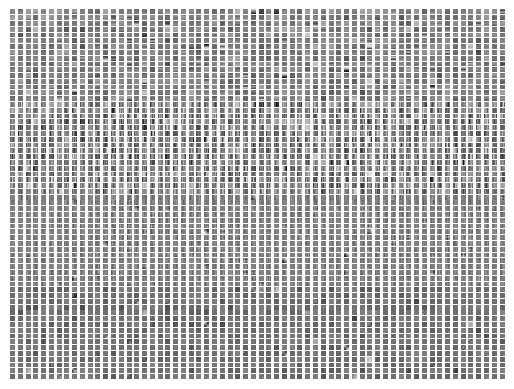

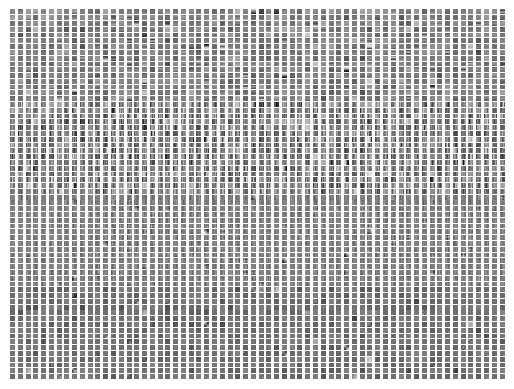

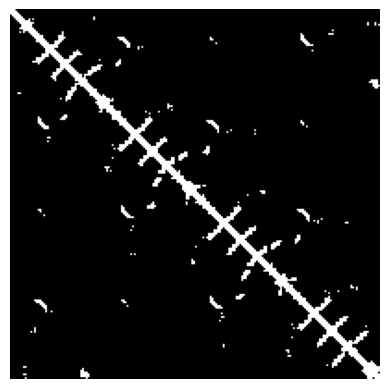

tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]]])


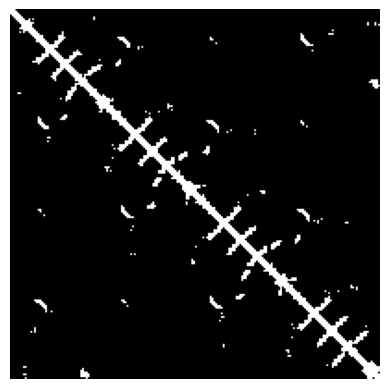

In [10]:
# Train data
train, target, length = train_data_pt[0]
print(train.shape)
train = train.squeeze(0)
torchshow.show(train)
print(f"{train}")
# This doesn't look how I expected it to, but the printed tensor does
torchshow.show(train)

# Target data
target = target
#print(target)
printMap(target.squeeze(0))
print(target)
printMap(target.squeeze(0), length)

# Creating a Convolutional Neural Network
There are likely ways to improve this code that I have not seen. I know for sure that I would like to incorporate a way to save the current state of the CNN, but that will have to be saved for another day... And likely the day I decide to actually fully train the CNN

In [11]:
torch.cuda.empty_cache()

class CNN(nn.Module):
    def __init__(self, feat, channels):
        super(CNN, self).__init__()

        self.prime = nn.Sequential(
            nn.Conv2d(feat, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.hidden = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.final = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=1),
        )

    def forward(self, x):
        x = self.prime(x)
        x = self.hidden(x)
        x = self.final(x)
        
        return x

In [12]:
loss_func = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0])).to(device)

def one_epoch(model, optimizer, train_loader):
    running_loss = 0
    last_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        torch.cuda.empty_cache()
        inputs, targets, length = data

        inputs = inputs.to(device)
        inputs = torch.nn.functional.normalize(inputs)

        targets = targets.to(device)

        outputs = model(inputs)
        
        loss = loss_func(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        running_loss += loss.item()
        if i % 1000 / batch == 250 / batch - 1:
            last_loss = running_loss # loss per batch
            print(f'  batch {i+1} loss: {last_loss}')
            running_loss = 0.
        
    return last_loss

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

def save_checkpoint(state, filename):
    print("Saving checkpoint")
    torch.save(state, filename)

def load_checkpoint(checkpoint, model, optimizer):
    print("Loading checkpoint")
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])

def train_CNN(model, epochs, train_loader, test_loader, checkpoint_dir = "checkpoint"):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    epoch_number = 0
    checkpoint_dir = checkpoint_dir + ".pth.tar"

    if os.path.isfile(checkpoint_dir):
        checkpoint = torch.load(checkpoint_dir)
        load_checkpoint(checkpoint, model, optimizer)


    for epoch in range(epochs):
        print('EPOCH {}:'.format(epoch_number + 1))

        model.train(True)

        avg_loss = one_epoch(model, optimizer, train_loader)
        running_vloss = 0.0
        model.eval()

        with torch.no_grad():
            for i, vdata in enumerate(test_loader, 1):
                vinputs, vlabels, vlength = vdata
                vinputs = vinputs.to(device)
                voutputs = model(vinputs)
                vlabels = vlabels.to(device)
                vloss = loss_func(voutputs, vlabels)
                running_vloss += vloss

        avg_vloss = running_vloss / (i + 1)
        print(f"Epoch {epoch}: LOSS train {avg_loss} valid {avg_vloss}")
        
        checkpoint = {'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict()}
        save_checkpoint(checkpoint, checkpoint_dir)

        epoch_number += 1

## Training CNN on VHSE Dataset

In [ ]:
batch = 1
epochs = 1  
train_loader = DataLoader(dataset = train_data, batch_size = batch, shuffle = True)
test_loader = DataLoader(dataset = test_data, batch_size = batch, shuffle = True)
vhse_model = CNN(32, 32)
vhse_model = vhse_model.to(device)

train_CNN(vhse_model, epochs, train_loader, test_loader, "vhse_chkpt")

Loading checkpoint
EPOCH 1:
  batch 250 loss: 108.01202414184809
  batch 1250 loss: 435.0327586904168
  batch 2250 loss: 426.40608529001474
  batch 3250 loss: 418.8694487474859
  batch 4250 loss: 416.18099887669086
  batch 5250 loss: 419.36509823054075
  batch 6250 loss: 413.7366975322366
  batch 7250 loss: 419.9876112341881
  batch 8250 loss: 417.572957649827
  batch 9250 loss: 413.1957107335329
  batch 10250 loss: 411.9251047708094
  batch 11250 loss: 411.2804056741297
  batch 12250 loss: 415.1328949704766
  batch 13250 loss: 408.9676165878773
Epoch 0: LOSS train 408.9676165878773 valid 26.120080947875977
Saving checkpoint
EPOCH 2:
  batch 250 loss: 100.18108892440796
  batch 1250 loss: 414.9329357743263
  batch 2250 loss: 406.7462625205517
  batch 3250 loss: 414.0422522947192
  batch 4250 loss: 405.26578848063946
  batch 5250 loss: 417.47836515307426
  batch 6250 loss: 410.3982967212796
  batch 7250 loss: 418.38483192771673
  batch 8250 loss: 409.7104684263468
  batch 9250 loss: 420

### Simple model test & demonstration

torch.Size([1, 1, 127, 127])
tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.]])
[[  21.99814      6.769009    11.368194  ...  -16.466337   -14.43448
   -10.583102 ]
 [   6.167807    11.948893    14.669534  ...  -15.595137   -12.213315
   -19.895597 ]
 [   9.003122    14.55372     17.175175  ...  -14.889057   -25.010662
   -21.655178 ]
 ...
 [ -14.885435   -12.007512   -10.467369  ... -129.51721   -377.02234
  -236.19513  ]
 [  -3.9378464   -8.422213   -14.519602  ... -218.9677    -154.06241
  -240.255    ]
 [  -2.1554785   -4.2835336   -7.479162  ... -160.83847     78.346886
   134.95274  ]]
Reading in from dataset files
Finished reading from files.
Name: 2KL1A 	Length: 87 
Residue Chain: ['M', 'N', 'E', 'A', 'K', 'G', 'V', 'Y', 'V', 'M', 'S', 'V', 'L', 'P', 'N', 'M', 'P', 'A', 'A', 'G'

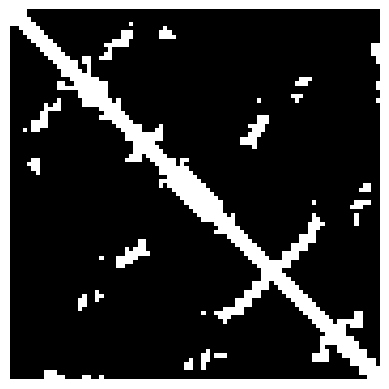

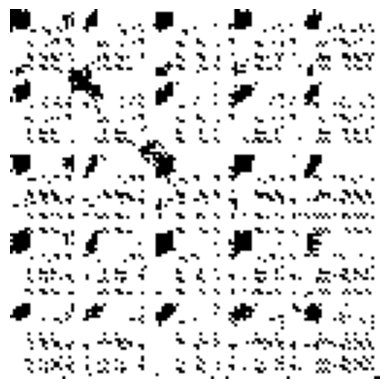

In [ ]:
tensor, label, length = test_data[0]
tensor = tensor.unsqueeze(0).to(device)
out_vhse = vhse_model(tensor)
print(out_vhse.shape)

out_vhse = out_vhse.to("cpu").squeeze().detach().numpy()
label = label.squeeze()
length = length.squeeze()

print(label)
print(out_vhse)
printMap(map, length)

out_vhse = applyThreshold(out_vhse, 0.3, length)
printMap(out_vhse, length)


## Training & Testing ProtTrans Data

In [16]:
batch = 1
train_loader = DataLoader(dataset = train_data_pt, batch_size = batch, shuffle = True)
test_loader = DataLoader(dataset = test_data_pt, batch_size = batch, shuffle = True)
pt_model = CNN(4096, 64)
pt_model = pt_model.to(device)
# Epochs is defined above with the VHSE data. I will keep them the same for now.
train_CNN(pt_model, epochs, train_loader, test_loader, "pt_chkpt")

Loading checkpoint
EPOCH 1:
  batch 250 loss: 85.05861185491085
  batch 1250 loss: 205.72185459826142
  batch 2250 loss: 196.9945212835446
  batch 3250 loss: 199.5802920232527
  batch 4250 loss: 193.57262363051996
  batch 5250 loss: 195.81336965737864
  batch 6250 loss: 194.40296507347375
  batch 7250 loss: 187.72624477744102
  batch 8250 loss: 189.57858246029355
  batch 9250 loss: 189.78536222409457
  batch 10250 loss: 195.17089429777116
  batch 11250 loss: 192.5096813174896
  batch 12250 loss: 182.29820114397444
  batch 13250 loss: 189.9483368487563
Epoch 0: LOSS train 189.9483368487563 valid 1.0878098011016846
Saving checkpoint
EPOCH 2:
  batch 250 loss: 46.98382930085063
  batch 1250 loss: 175.6555291726254
  batch 2250 loss: 182.08880575583316
  batch 3250 loss: 173.2012995018158
  batch 4250 loss: 175.61681753071025
  batch 5250 loss: 178.9356707574334
  batch 6250 loss: 190.49493754049763
  batch 7250 loss: 185.34505398140755
  batch 8250 loss: 176.08841281034984
  batch 9250 lo

KeyboardInterrupt: 

In [29]:
i = 0

### Visual Test & Display of PT CNN

torch.Size([4096, 200, 200])
torch.Size([1, 200, 200])
torch.Size([1, 200, 200])
tensor([[[1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         [1., 1., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]]])
[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 

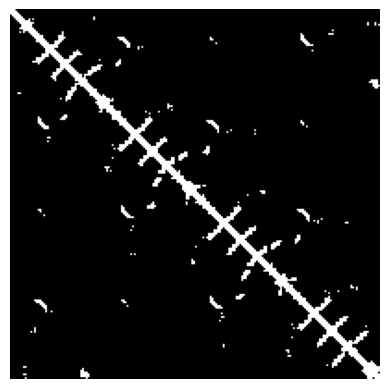

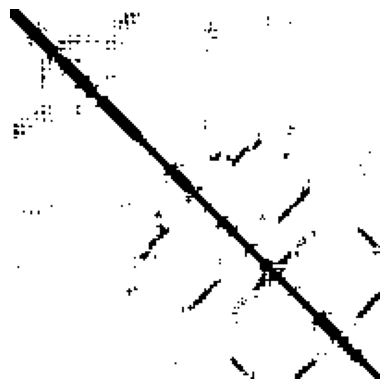

In [31]:
torch.cuda.empty_cache()

tensor, label, length = test_data_pt[i]
print(tensor.shape)
print(label.shape)
tensor = tensor.to(device)
out_pt = pt_model(tensor)
print(out_pt.shape)
out_pt = out_pt.to("cpu")[0].detach().numpy()
out_pt = applyThreshold(out_pt, 1, length)
print(target)
print(out_pt)
printMap(target.squeeze(), length)
printMap(out_pt, length)
i += 1 